<a href="https://colab.research.google.com/github/leshaz44/Aliaksei/blob/main/Task_6/Task_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


154/154 ━━━━━━━━━━━━━━━━━━━━ 11s 50ms/step - loss: 0.0024
Epoch 2/5
154/154 ━━━━━━━━━━━━━━━━━━━━ 7s 47ms/step - loss: 7.0840e-04
Epoch 3/5
154/154 ━━━━━━━━━━━━━━━━━━━━ 10s 43ms/step - loss: 5.9037e-04
Epoch 4/5
154/154 ━━━━━━━━━━━━━━━━━━━━ 8s 50ms/step - loss: 5.2054e-04
Epoch 5/5
154/154 ━━━━━━━━━━━━━━━━━━━━ 10s 49ms/step - loss: 4.3986e-04
154/154 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
RMSE на обучающей выборке: 35.38
RMSE на тестовой выборке: 109.77
MAE на обучающей выборке: 25.99
MAE на тестовой выборке: 88.19


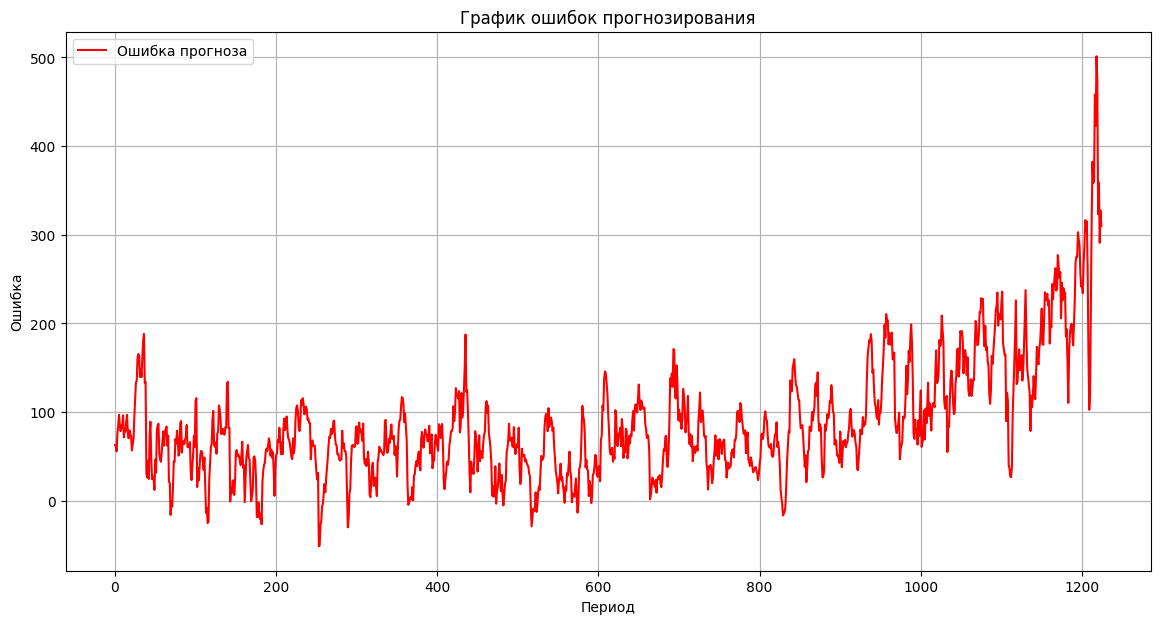

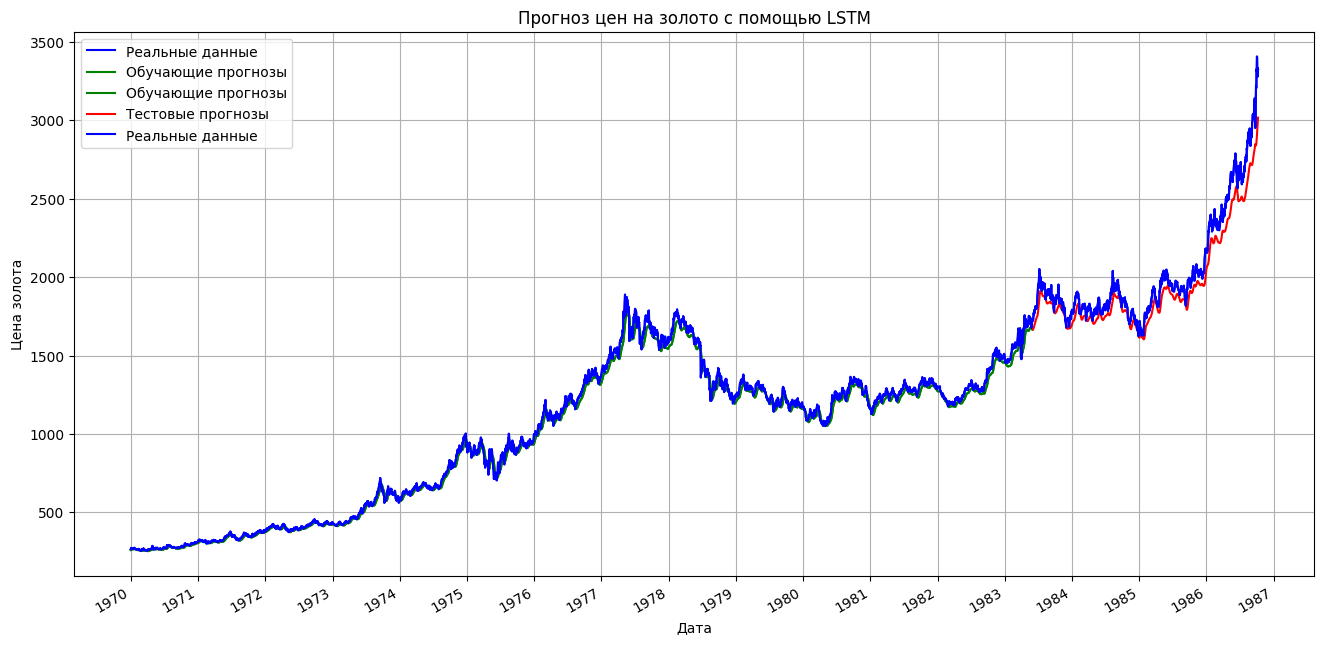

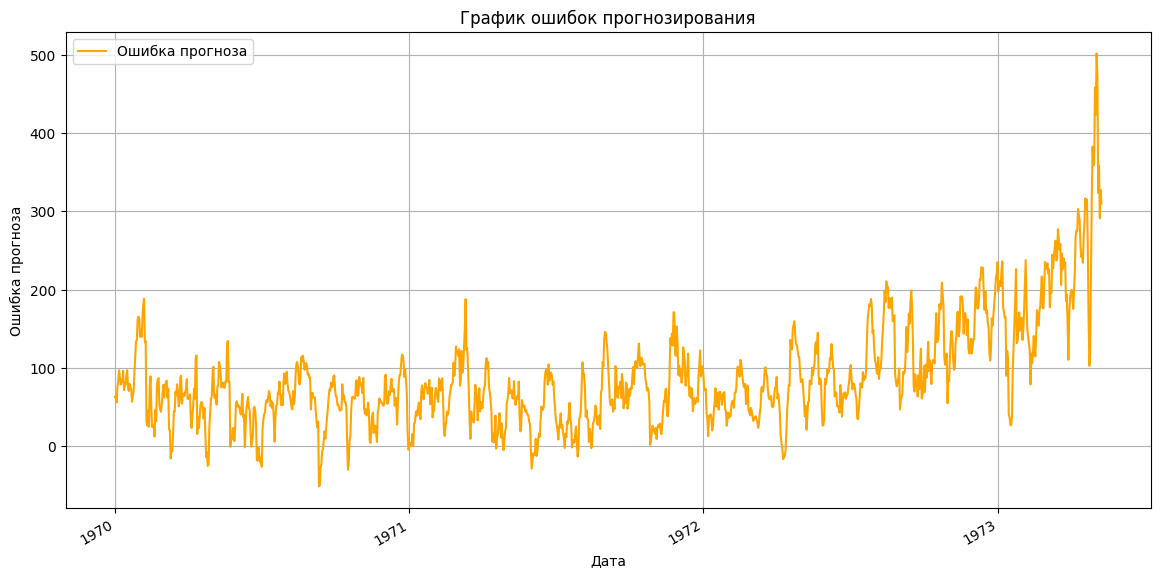

Метрики качества на обучающей выборке:
RMSE: 35.38
MAE: 25.99
R2: 0.99

Метрики качества на тестовой выборке:
RMSE: 109.77
MAE: 88.19
R2: 0.90


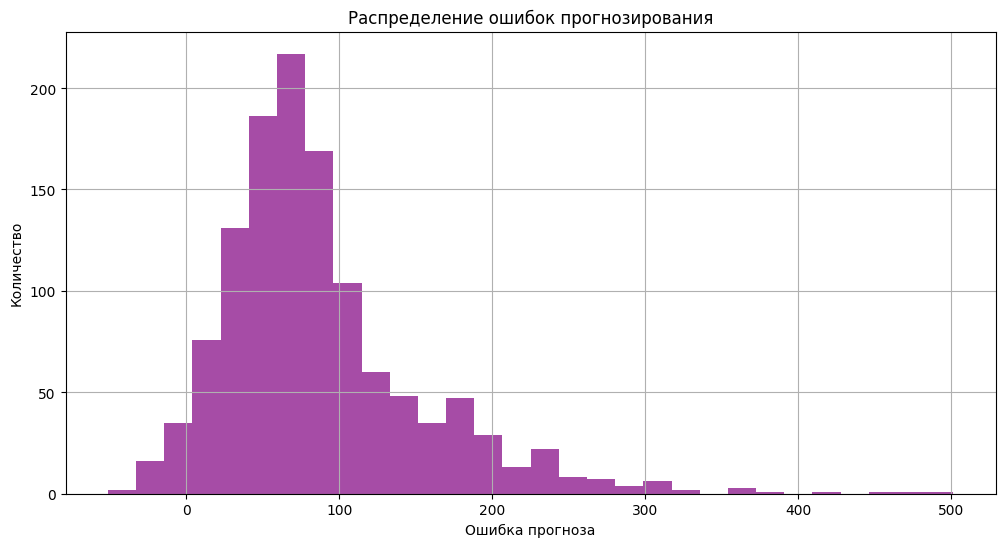

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
import matplotlib.dates as mdates

# Загрузка данных
df = pd.read_csv('Futures_Resources_Data.csv', parse_dates=['Date'])
df.set_index('Date', inplace=True)

# Выбираем только данные по золоту
gold_data = df['GC=F_closing_price'].dropna()

# Нормализация данных
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(gold_data.values.reshape(-1,1))

# Создание обучающих последовательностей
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data)-seq_length):
        X.append(data[i:(i+seq_length)])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

sequence_length = 60
X, y = create_sequences(scaled_data, sequence_length)

# Разделение на выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Построение модели LSTM
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=1))

model.compile(optimizer='adam', loss='mean_squared_error')

# Обучение модели
model.fit(X_train, y_train, epochs=5, batch_size=32)

# Прогнозирование
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# Обратное преобразование масштабирования
train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)
y_true = scaler.inverse_transform(y.reshape(-1,1))

# Метрики качества
train_rmse = np.sqrt(mean_squared_error(y_true[:len(train_predict)], train_predict))
test_rmse = np.sqrt(mean_squared_error(y_true[-len(test_predict):], test_predict))
train_mae = mean_absolute_error(y_true[:len(train_predict)], train_predict)
test_mae = mean_absolute_error(y_true[-len(test_predict):], test_predict)

print(f"RMSE на обучающей выборке: {train_rmse:.2f}")
print(f"RMSE на тестовой выборке: {test_rmse:.2f}")
print(f"MAE на обучающей выборке: {train_mae:.2f}")
print(f"MAE на тестовой выборке: {test_mae:.2f}")

# График ошибок
plt.figure(figsize=(14, 7))
plt.plot(y_true[-len(test_predict):] - test_predict, label='Ошибка прогноза', color='red')
plt.title('График ошибок прогнозирования')
plt.xlabel('Период')
plt.ylabel('Ошибка')
plt.legend()
plt.grid(True)
plt.show()

# График сравнения реальных и предсказанных значений
plt.figure(figsize=(16, 8))
plt.plot(gold_data.index[sequence_length:], y_true, label='Реальные данные', color='blue')
plt.plot(gold_data.index[sequence_length:len(train_predict)+sequence_length], train_predict, label='Обучающие прогнозы', color='green')
plt.plot(gold_data.index[sequence_length:len(train_predict)+sequence_length],
         train_predict,
         label='Обучающие прогнозы',
         color='green')

plt.plot(gold_data.index[-len(test_predict):],
         test_predict,
         label='Тестовые прогнозы',
         color='red')

plt.plot(gold_data.index[sequence_length:],
         y_true,
         label='Реальные данные',
         color='blue')

plt.title('Прогноз цен на золото с помощью LSTM')
plt.xlabel('Дата')
plt.ylabel('Цена золота')
plt.legend()
plt.grid(True)
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.gcf().autofmt_xdate()
plt.show()

# График ошибок прогнозирования
plt.figure(figsize=(14, 7))
plt.plot(gold_data.index[-len(test_predict):],
         y_true[-len(test_predict):] - test_predict,
         label='Ошибка прогноза',
         color='orange')
plt.title('График ошибок прогнозирования')
plt.xlabel('Дата')
plt.ylabel('Ошибка прогноза')
plt.legend()
plt.grid(True)
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.gcf().autofmt_xdate()
plt.show()

# Метрики качества модели
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Для обучающей выборки
train_rmse = np.sqrt(mean_squared_error(y_true[:len(train_predict)], train_predict))
train_mae = mean_absolute_error(y_true[:len(train_predict)], train_predict)
train_r2 = r2_score(y_true[:len(train_predict)], train_predict)

# Для тестовой выборки
test_rmse = np.sqrt(mean_squared_error(y_true[-len(test_predict):], test_predict))
test_mae = mean_absolute_error(y_true[-len(test_predict):], test_predict)
test_r2 = r2_score(y_true[-len(test_predict):], test_predict)

print("Метрики качества на обучающей выборке:")
print(f"RMSE: {train_rmse:.2f}")
print(f"MAE: {train_mae:.2f}")
print(f"R2: {train_r2:.2f}")

print("\nМетрики качества на тестовой выборке:")
print(f"RMSE: {test_rmse:.2f}")
print(f"MAE: {test_mae:.2f}")
print(f"R2: {test_r2:.2f}")

# Важность признаков
# Для LSTM модели с одним признаком (цена) важность признаков не оценивается
# так как модель учитывает временные зависимости, а не важность отдельных признаков

# Гистограмма распределения ошибок
plt.figure(figsize=(12, 6))
plt.hist(y_true[-len(test_predict):] - test_predict, bins=30, color='purple', alpha=0.7)
plt.title('Распределение ошибок прогнозирования')
plt.xlabel('Ошибка прогноза')
plt.ylabel('Количество')
plt.grid(True)
plt.show()